<a href="https://colab.research.google.com/github/RenintaJP/Smart-Irrigation/blob/code/SMART%20IRRIGATION%20USING%20LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Load Dataset
df = pd.read_csv('Dataset Smart Irrigation - Sheet26.csv')

# 2. Gabungkan Tanggal & Waktu menjadi Index Datetime
df['Datetime'] = pd.to_datetime(df['Tanggal'] + ' ' + df['Waktu'])
df = df.sort_values('Datetime').set_index('Datetime')

# 3. One-Hot Encoding untuk kolom 'Status'
df_encoded = pd.get_dummies(df, columns=['Status'], dtype=int)

# 4. CARA OTOMATIS: Ambil semua kolom yang ada, tapi pastikan 'Soil' tetap di urutan PERTAMA (indeks 0)
# Kita abaikan kolom 'Tanggal' dan 'Waktu' karena sudah jadi indeks
feature_cols = ['M_Soil'] + [col for col in df_encoded.columns if col not in ['Tanggal', 'Waktu', 'M_Soil']]

print("Kolom fitur yang digunakan saat ini:")
print(feature_cols)

# Ambil nilainya
data = df_encoded[feature_cols].values

# 5. Scaling Data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("\nData berhasil di-load dan diproses! Jumlah baris & kolom:", scaled_data.shape)

Kolom fitur yang digunakan saat ini:
['M_Soil', 'T_Soil', 'T_Air', 'H_Air', 'Lux', 'pH', 'N', 'P', 'K', 'Status_Kering']

Data berhasil di-load dan diproses! Jumlah baris & kolom: (25, 10)


SLIDING WINDOW

In [ ]:
def create_multivariate_windows(data, time_steps=5):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, :])
    return np.array(X), np.array(y)

# Kita gunakan 5 baris data sebelumnya untuk memprediksi 1 data ke depan
TIME_STEPS = 5
X, y = create_multivariate_windows(scaled_data, TIME_STEPS)

print(f"Bentuk Input X: {X.shape}") # Format: [samples, time_steps, features]
print(f"Bentuk Target y: {y.shape}")

Bentuk Input X: (20, 5, 10)
Bentuk Target y: (20, 10)


SPLIT DATA & PEMBUATAN MODEL

In [ ]:
# 1. TAMBAHKAN IMPORT INI DI PALING ATAS AGAR TIDAK NAMEERROR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Pastikan menggunakan Input(shape=...) sebagai layer pertama (rekomendasi baru Keras)
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Jalankan ulang training
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

# 3. Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Training Model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.2587 - mae: 0.4136 - val_loss: 0.1096 - val_mae: 0.3187
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step - loss: 0.2174 - mae: 0.3673 - val_loss: 0.0886 - val_mae: 0.2837
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.1997 - mae: 0.3539 - val_loss: 0.0696 - val_mae: 0.2475
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1565 - mae: 0.3129 - val_loss: 0.0537 - val_mae: 0.2123
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.1306 - mae: 0.2952 - val_loss: 0.0405 - val_mae: 0.1774
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1185 - mae: 0.2786 - val_loss: 0.0298 - val_mae: 0.1546
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.1081 - mae: 0.2692 - val_loss: 0.0215 - val_mae: 0.1387
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0778 - mae: 0.2330 - val_loss: 0.0154 - val_mae: 0.1227
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0947 - mae: 0.2

CORRELATION MATRIX

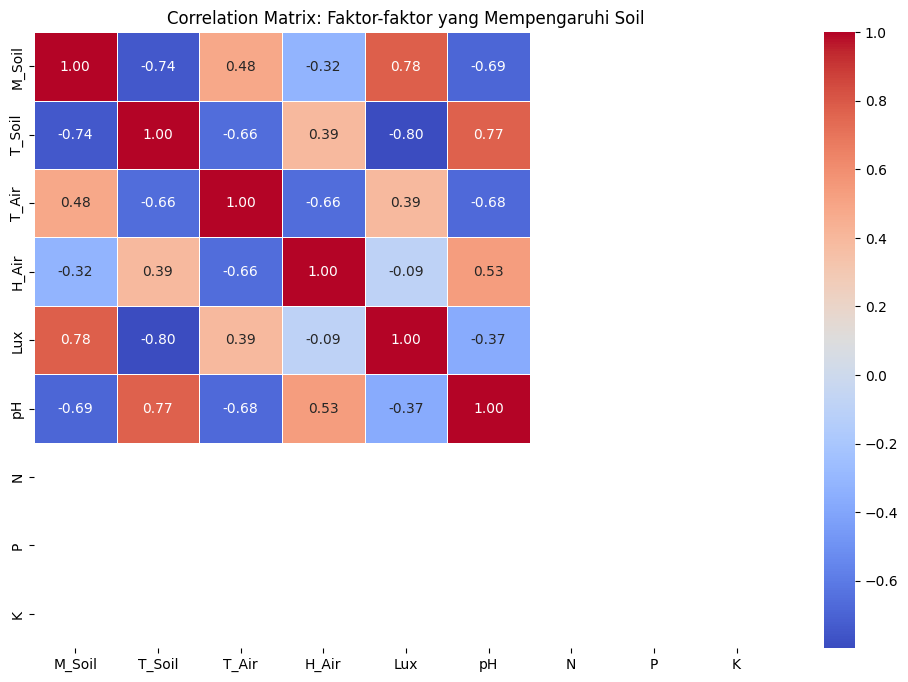

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset (pastikan sudah diproses seperti langkah sebelumnya)
df = pd.read_csv('Dataset Smart Irrigation - Sheet26.csv')

# 2. Karena status hanya berisi 'Kering', kita bisa mengabaikannya
# atau encode secara manual jika nanti ada variasi lain
df_numeric = df.drop(columns=['Tanggal', 'Waktu', 'Status'])

# 3. Hitung Matriks Korelasi
corr_matrix = df_numeric.corr()

# 4. Visualisasikan dengan Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Faktor-faktor yang Mempengaruhi Soil')
plt.show()

MENAMPILKAN STATISTIK DESKRIPTIF

In [ ]:
# Menampilkan ringkasan statistik (mean, min, max, std dev)
print(df.describe())

       M_Soil     T_Soil      T_Air      H_Air           Lux         pH     N  \
count   25.00  25.000000  25.000000  25.000000     25.000000  25.000000  25.0   
mean    53.32  33.480000  33.000000  61.080000  17099.760000   8.160000   0.0   
std      1.60   3.776242   3.122499   7.505109  16747.973846   1.795364   0.0   
min     51.00  27.000000  31.000000  45.000000   2843.000000   3.000000   0.0   
25%     52.00  31.000000  32.000000  55.000000   3509.000000   9.000000   0.0   
50%     53.00  34.000000  32.000000  60.000000   5324.000000   9.000000   0.0   
75%     55.00  37.000000  32.000000  68.000000  37955.000000   9.000000   0.0   
max     56.00  38.000000  43.000000  73.000000  41932.000000   9.000000   0.0   

          P     K  
count  25.0  25.0  
mean    0.0   0.0  
std     0.0   0.0  
min     0.0   0.0  
25%     0.0   0.0  
50%     0.0   0.0  
75%     0.0   0.0  
max     0.0   0.0  


MENGECEK TREN WAKTU (TIME SERIES PLOT)

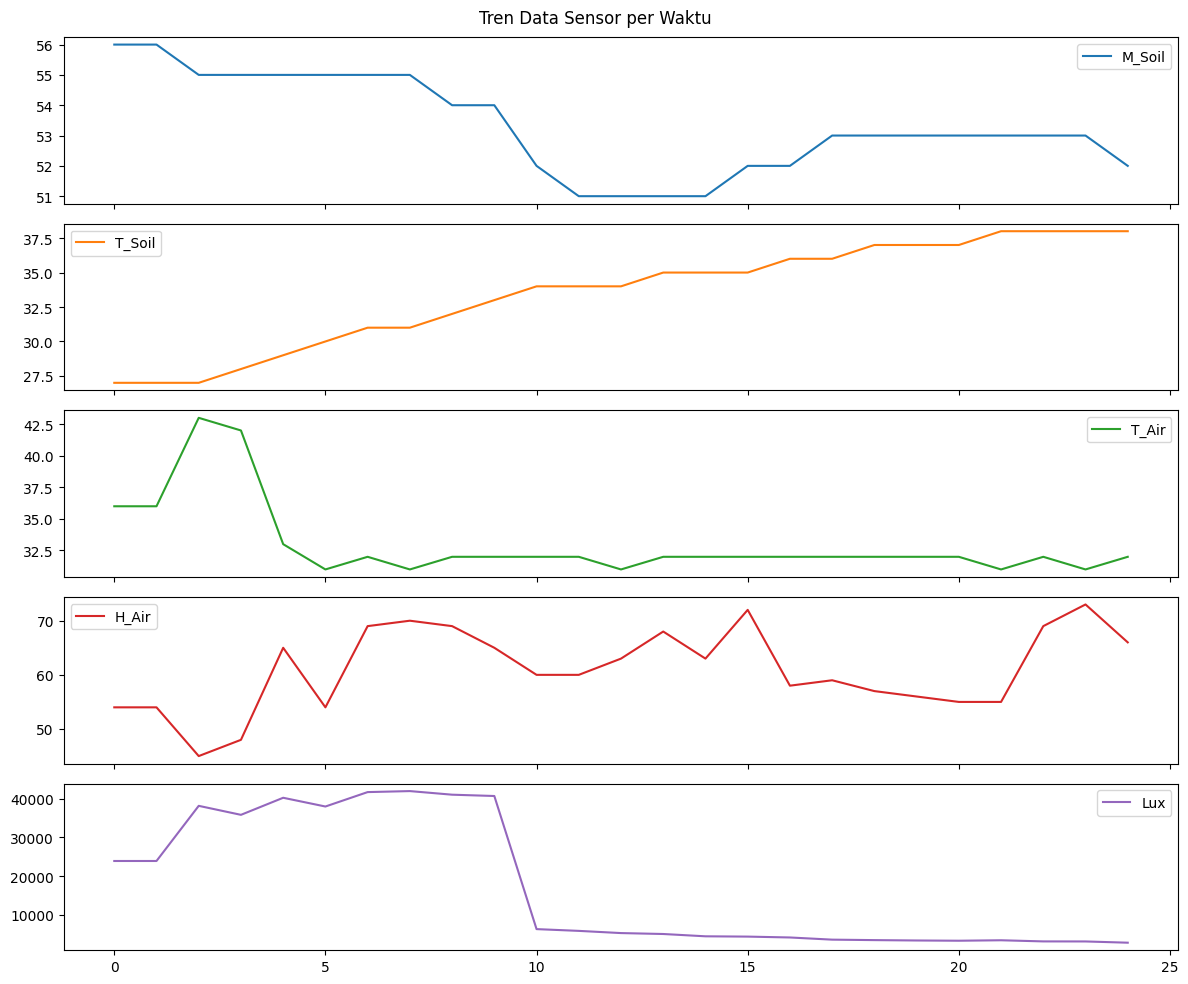

In [55]:
import matplotlib.pyplot as plt

# Plotting setiap kolom numerik
cols_to_plot = ['M_Soil', 'T_Soil', 'T_Air', 'H_Air', 'Lux']
df[cols_to_plot].plot(subplots=True, figsize=(12, 10), title="Tren Data Sensor per Waktu")
plt.tight_layout()
plt.show()

ANALISIS DISTRIBUSI (HISTOGRAM)

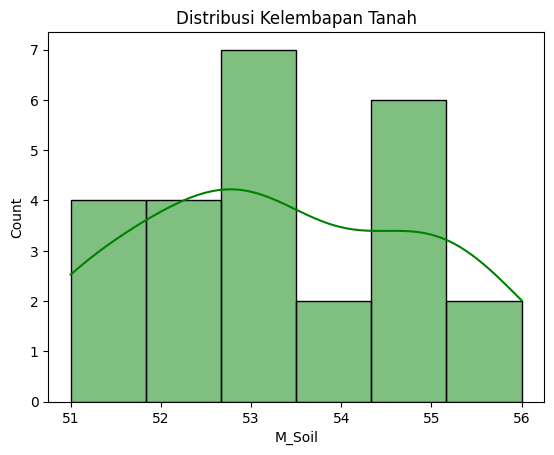

In [ ]:
# Melihat distribusi nilai Soil
sns.histplot(df['M_Soil', ], kde=True, color='green')
plt.title('Distribusi Kelembapan Tanah')
plt.show()

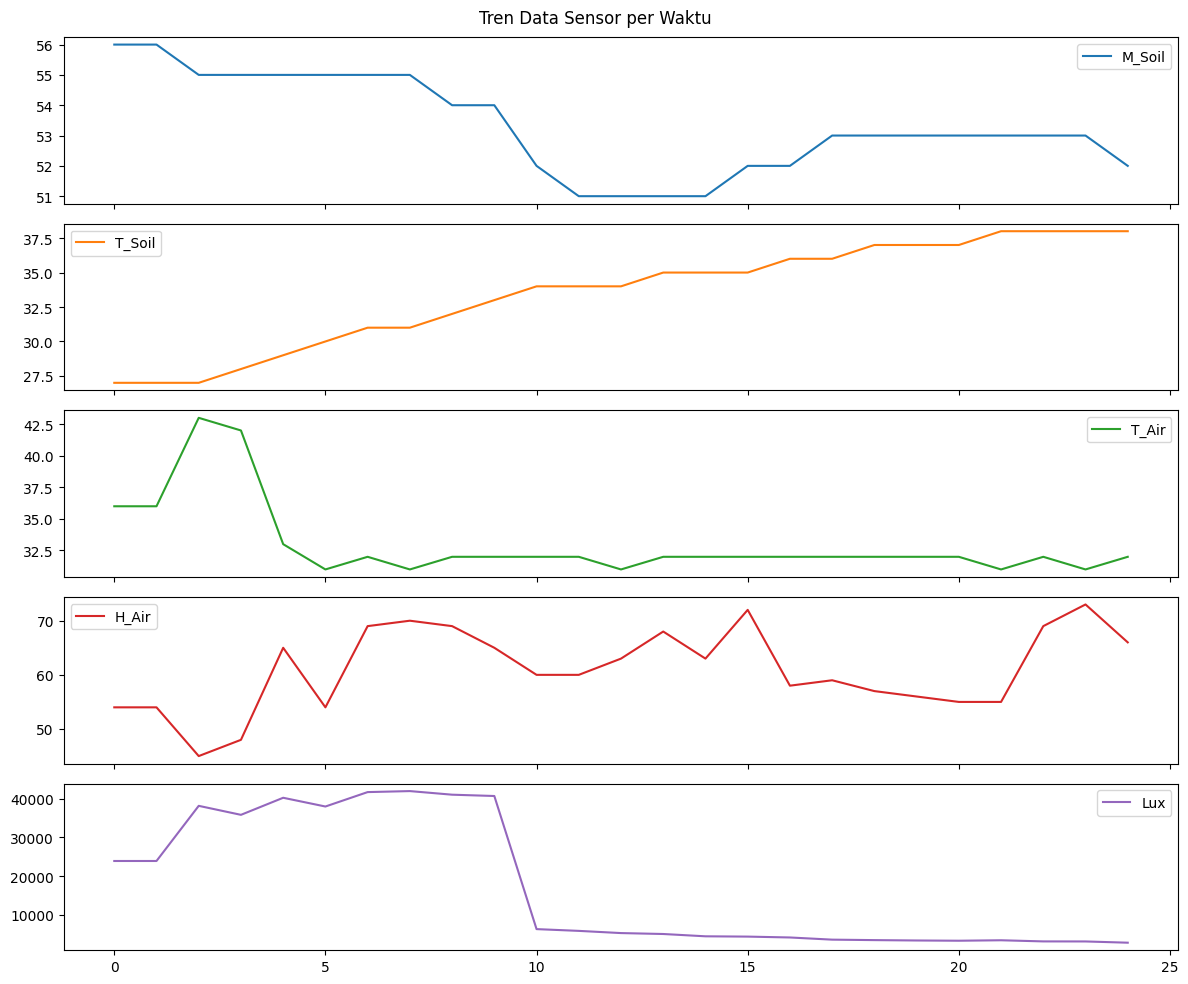

In [ ]:
import matplotlib.pyplot as plt

# Plotting setiap kolom numerik
cols_to_plot = ['M_Soil', 'T_Soil', 'T_Air', 'H_Air', 'Lux']
df[cols_to_plot].plot(subplots=True, figsize=(12, 10), title="Tren Data Sensor per Waktu")
plt.tight_layout()
plt.show()

ANALISIS DISTRIBUSI (HISTOGRAM)

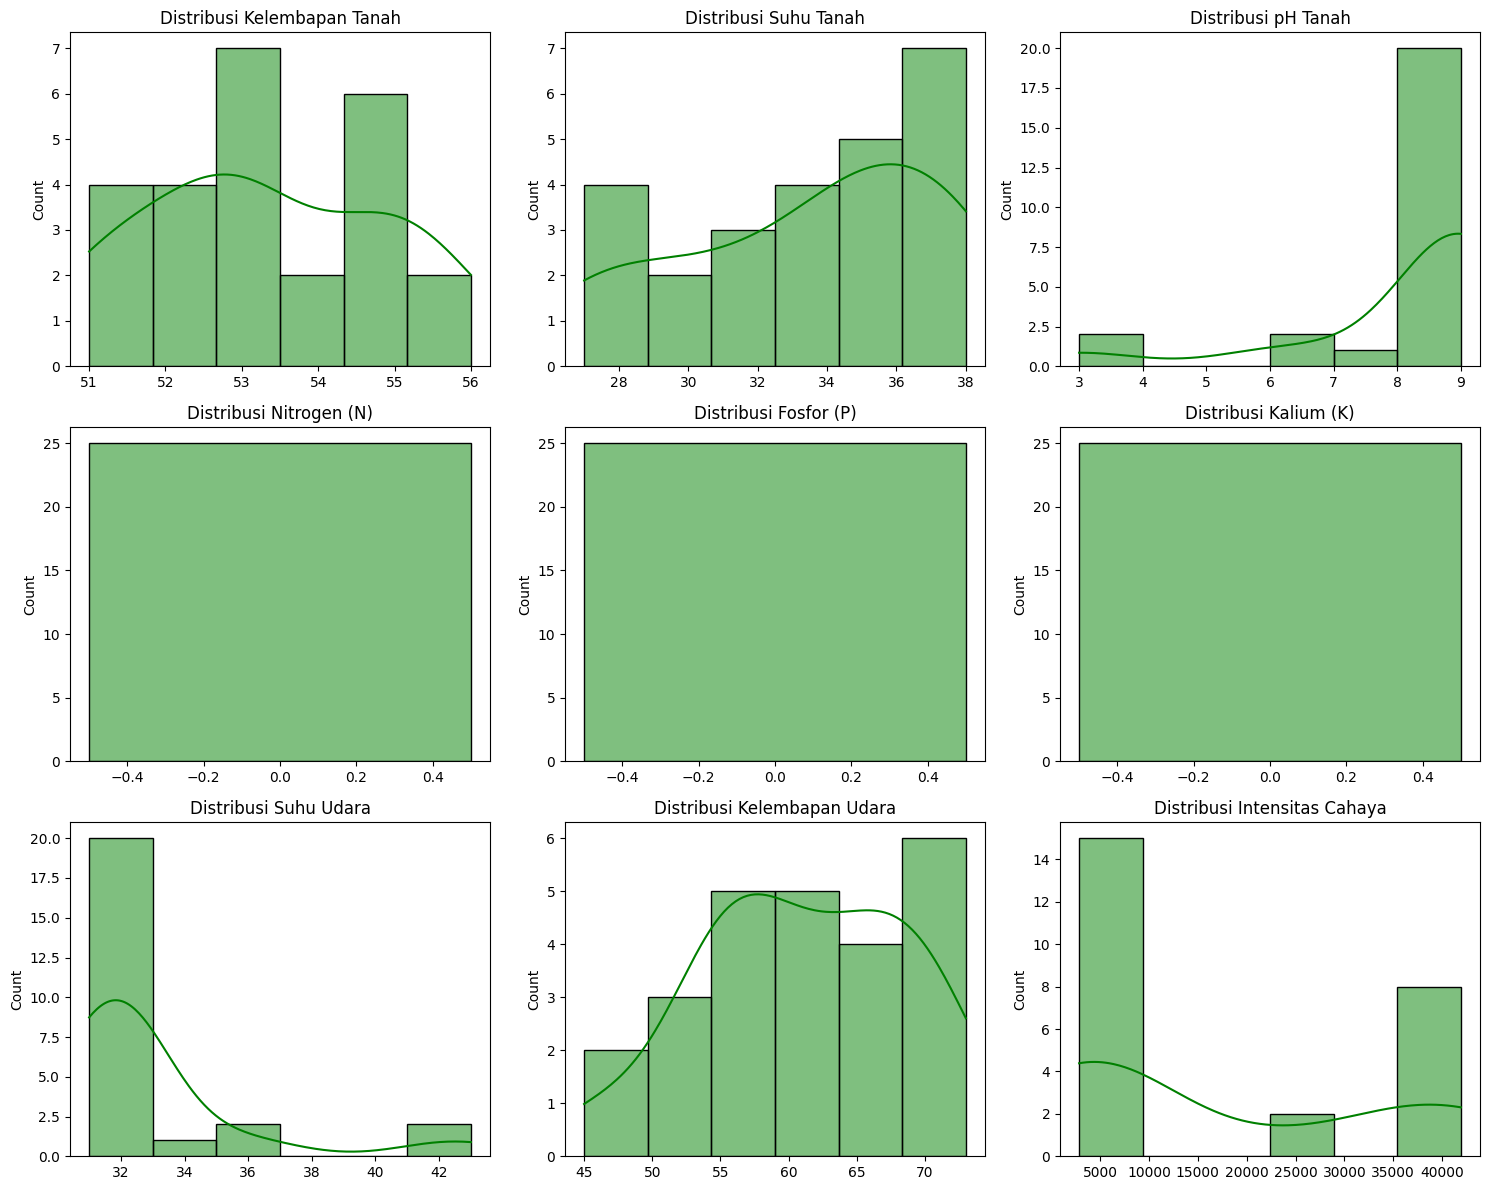

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daftar kolom yang ingin divisualisasikan beserta judulnya
columns = {
    'M_Soil': 'Distribusi Kelembapan Tanah',
    'T_Soil': 'Distribusi Suhu Tanah',
    'pH': 'Distribusi pH Tanah',
    'N': 'Distribusi Nitrogen (N)',
    'P': 'Distribusi Fosfor (P)',
    'K': 'Distribusi Kalium (K)',
    'T_Air': 'Distribusi Suhu Udara',
    'H_Air': 'Distribusi Kelembapan Udara',
    'Lux': 'Distribusi Intensitas Cahaya'
}

# Membuat layout subplot (3 baris, 3 kolom)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # Mengubah matriks 3x3 menjadi list 1D agar mudah diakses

# Loop untuk membuat plot
for i, (col, title) in enumerate(columns.items()):
    sns.histplot(df[col], kde=True, color='green', ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('') # Menghilangkan label x agar lebih bersih

# Menghapus subplot kosong jika ada (jika jumlah kolom tidak pas dengan grid)
plt.tight_layout()
plt.show()

PREDIKSI & EVALUASI

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


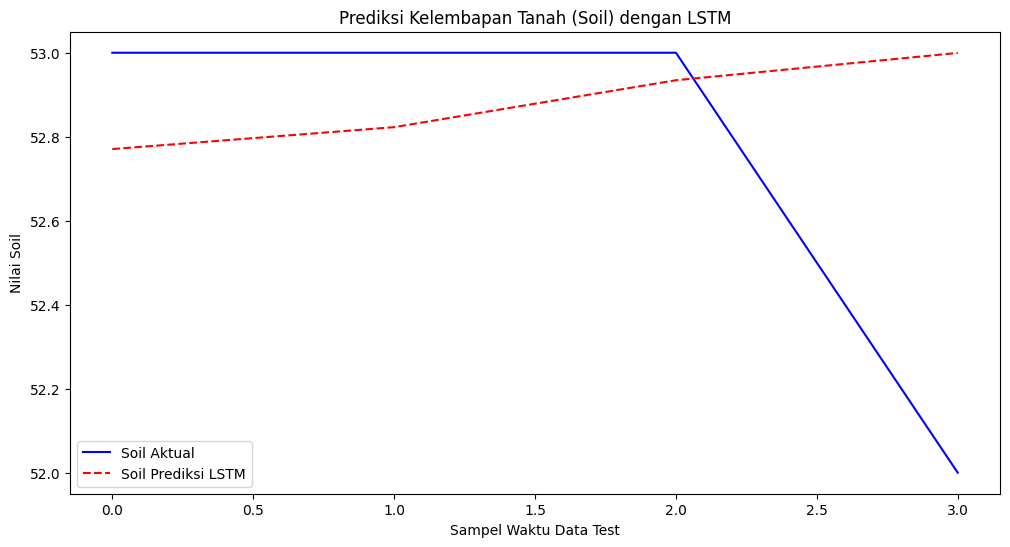

In [ ]:
# 1. TAMBAHKAN IMPORT
import matplotlib.pyplot as plt
import numpy as np

# 2. Lakukan Prediksi seperti biasa
predictions = model.predict(X_test)

# Trik Inverse Transform untuk 1 Kolom Target dari Banyak Fitur
dummy_pred = np.zeros((len(predictions), len(feature_cols)))
dummy_pred[:, 0] = predictions.flatten()
predictions_actual = scaler.inverse_transform(dummy_pred)[:, 0]

# Lakukan hal yang sama untuk nilai aktual (y_test)
dummy_actual = np.zeros((len(y_test), len(feature_cols)))
dummy_actual[:, 0] = y_test
y_test_actual = scaler.inverse_transform(dummy_actual)[:, 0]

# 3. Visualisasi Hasil Prediksi vs Aktual (Sekarang tidak akan error)
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Soil Aktual', color='blue')
plt.plot(predictions_actual, label='Soil Prediksi LSTM', color='red', linestyle='--')
plt.title('Prediksi Kelembapan Tanah (Soil) dengan LSTM')
plt.xlabel('Sampel Waktu Data Test')
plt.ylabel('Nilai Soil')
plt.legend()
plt.show()